# 🎱 TOTO Optimizer v3
**Strategy:** Prize sharing minimisation + Lucky feel + Statistical analysis

TOTO differs from 4D in two critical ways:
1. **Group 1 prize is SHARED** — if 5 people pick the same 6 numbers, the jackpot splits 5 ways
2. **Snowball draws** — unclaimed Group 1 prize cascades to next draw, creating massive jackpots

This notebook combines:
- 📊 **Hot/Cold balls** + pair frequency heatmap
- 🎲 **Pure random 7** (unbiased)
- 🔮 **Lucky feel** (your numbers as anchors + cold fillers)
- 🪞 **Mirror number** folk formula (last draw → +6 → mirror digits)
- ⚙️ **Wheeling system** (full combo coverage calculator)
- 🗓️ **Almanac feng shui** — best time, direction & outlet to buy TODAY

**Rerun:** Every Monday and Thursday before TOTO draw.

---
## ⚙️ BLOCK 1 — Config, Imports & Your Lucky Numbers

In [1]:
import sqlite3
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from itertools import combinations
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
np.random.seed(None)   # true randomness each run

# ── DB CONFIG ────────────────────────────────────────────────────────────────
DB_PATH    = 'data/toto_results.db'   # ← update if needed
NUM_COLS   = ['num1','num2','num3','num4','num5','num6']
COMBO_SIZE = 7     # System 7 entry (covers all 7-number combos)
                   # Change to 6 for standard entry
TOP_N      = 5     # number of combo recommendations in final output
os.makedirs('output', exist_ok=True)

# ── ✏️  YOUR LUCKY NUMBERS — EDIT THIS SECTION ──────────────────────────────
# Format: ('NN', 'reason') — single numbers 1–49
# These seed your lucky combo derivation in Block 7

LUCKY_NUMBERS = [
    # Examples — replace with your own:
    # ('7',  'Lucky number'),
    # ('27', 'My birthday date'),
    # ('16', 'Father\'s block number'),
    # ('38', 'Auspicious — 3+8=11, 1+1=2, balance'),
    # ('49', 'Max ball — feels complete'),
    ('2', 'My birth Month'),
    ('27', 'My birth Day'),
    ('48', 'My age'),
    ('6', 'Sister birth day'),
    ('1', 'Sister birth Month'),
    ('16', 'Father Mandai'),
]

# ─────────────────────────────────────────────────────────────────────────────
print('✅ Config loaded.')
print(f'   DB        : {DB_PATH}')
print(f'   Entry     : System {COMBO_SIZE}')
print(f'   Lucky nums: {[n for n,_ in LUCKY_NUMBERS] if LUCKY_NUMBERS else "None entered"}')

✅ Config loaded.
   DB        : data/toto_results.db
   Entry     : System 7
   Lucky nums: ['2', '27', '48', '6', '1', '16']


---
## 🔍 BLOCK 2 — Load & Validate Data

In [2]:
conn = sqlite3.connect(DB_PATH)

# Schema check
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
print(f'Tables   : {[t[0] for t in tables]}')
print(f'DB exists: {os.path.exists(DB_PATH)}')

cols = [row[1] for row in conn.execute('PRAGMA table_info(draws)').fetchall()]
print(f'Columns  : {cols}')

# Check if v2 columns exist
has_locations = 'g1_locations' in cols
has_snowball  = 'g1_snowball'  in cols
has_expiry    = 'prize_expiry' in cols
print(f'\nv2 columns present:')
print(f'  g1_locations : {"✅" if has_locations else "❌ Run new scrape_toto.py first"}')
print(f'  g1_snowball  : {"✅" if has_snowball  else "❌ Run new scrape_toto.py first"}')
print(f'  prize_expiry : {"✅" if has_expiry    else "❌ Run new scrape_toto.py first"}')

# Load all draws
df = pd.read_sql('SELECT * FROM draws ORDER BY draw_number ASC', conn)
df['draw_date'] = pd.to_datetime(df['draw_date'], errors='coerce')

# Filter to valid draws only (reliable date + all 6 numbers present)
df_valid = df[
    (df['date_reliable'] == 1) &
    df[NUM_COLS].notnull().all(axis=1)
].copy().reset_index(drop=True)

for col in NUM_COLS:
    df_valid[col] = df_valid[col].astype(int)

print(f'\n✅ Total draws in DB      : {len(df):,}')
print(f'   Valid draws (reliable) : {len(df_valid):,}')
print(f'   Date range             : {df_valid["draw_date"].min().date()} → {df_valid["draw_date"].max().date()}')
display(df_valid[['draw_number','draw_date'] + NUM_COLS + ['additional','jackpot_prize','g1_winners']].tail(5))

Tables   : ['draws']
DB exists: True
Columns  : ['draw_number', 'draw_date', 'date_reliable', 'num1', 'num2', 'num3', 'num4', 'num5', 'num6', 'additional', 'jackpot_prize', 'g1_amount', 'g1_winners', 'g2_amount', 'g2_winners', 'g3_amount', 'g3_winners', 'g4_amount', 'g4_winners', 'g5_amount', 'g5_winners', 'g6_amount', 'g6_winners', 'g7_amount', 'g7_winners', 'scraped_at', 'g1_locations', 'g1_snowball', 'g2_locations', 'prize_expiry']

v2 columns present:
  g1_locations : ✅
  g1_snowball  : ✅
  prize_expiry : ✅

✅ Total draws in DB      : 3,168
   Valid draws (reliable) : 2,975
   Date range             : 1997-07-03 → 2026-04-13


,draw_number,draw_date,num1,num2,num3,num4,num5,num6,additional,jackpot_prize,g1_winners
2970,4169,2026-03-30,4,12,26,30,46,47,6,"$2,962,260",NaN
2971,4170,2026-04-02,1,7,8,23,30,33,21,"$5,715,685",1.0
2972,4171,2026-04-06,14,23,29,30,39,48,12,"$1,253,943",NaN
2973,4172,2026-04-09,1,2,6,9,44,48,24,"$2,971,831",1.0
2974,4173,2026-04-13,4,8,10,15,16,26,17,"$1,267,460",5.0


---
## 📊 BLOCK 3 — Ball Frequency Analysis
How often has each ball 1–49 appeared across all valid draws?
TOTO draws 6 balls per draw — expected frequency = `total_draws × 6 / 49`.

Valid draws analysed : 2,975
Expected freq/ball   : 364.3 draws
Most drawn  : #17 (424 times)
Least drawn : #47 (136 times)

🔴 Top 7 HOT balls   : [11, 12, 15, 17, 22, 30, 31]  counts=[406, 417, 408, 424, 420, 407, 416]
🔵 Top 7 COLD balls  : [3, 26, 45, 46, 47, 48, 49]   counts=[355, 343, 343, 158, 136, 149, 157]


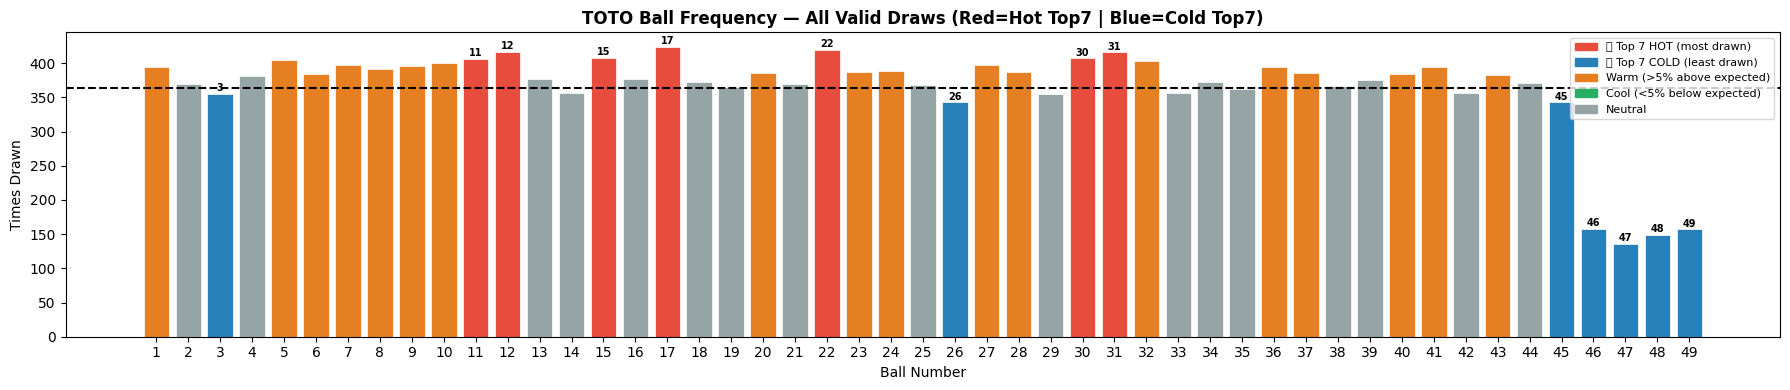

📊 Saved: output/toto_v2_block3_frequency.png


In [3]:
# Flatten all winning numbers
all_nums = pd.Series(
    df_valid[NUM_COLS].values.flatten().astype(int)
)
freq = all_nums.value_counts().sort_index()
freq = freq.reindex(range(1, 50), fill_value=0)

total_draws  = len(df_valid)
expected_freq = total_draws * 6 / 49   # always 6 — hardcoded, not COMBO_SIZE

print(f'Valid draws analysed : {total_draws:,}')
print(f'Expected freq/ball   : {expected_freq:.1f} draws')
print(f'Most drawn  : #{freq.idxmax()} ({freq.max()} times)')
print(f'Least drawn : #{freq.idxmin()} ({freq.min()} times)')

# Top 7 and bottom 7
top7_high = freq.nlargest(7).index.tolist()
top7_low  = freq.nsmallest(7).index.tolist()

print(f'\n🔴 Top 7 HOT balls   : {sorted(top7_high)}  counts={[int(freq[n]) for n in sorted(top7_high)]}')
print(f'🔵 Top 7 COLD balls  : {sorted(top7_low)}   counts={[int(freq[n]) for n in sorted(top7_low)]}')

# ── Chart ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))
colors = []
for n in range(1, 50):
    if n in top7_high:
        colors.append('#e74c3c')   # hot red
    elif n in top7_low:
        colors.append('#2980b9')   # cold blue
    elif freq[n] > expected_freq * 1.05:
        colors.append('#e67e22')   # warm
    elif freq[n] < expected_freq * 0.95:
        colors.append('#27ae60')   # cool
    else:
        colors.append('#95a5a6')   # neutral

bars = ax.bar(freq.index, freq.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(expected_freq, color='black', linestyle='--', linewidth=1.5,
           label=f'Expected ({expected_freq:.0f})')

# Label top and bottom 7
for n in top7_high + top7_low:
    ax.text(n, freq[n] + 1, str(n), ha='center', va='bottom', fontsize=7, fontweight='bold')

patches = [
    mpatches.Patch(color='#e74c3c', label='🔴 Top 7 HOT (most drawn)'),
    mpatches.Patch(color='#2980b9', label='🔵 Top 7 COLD (least drawn)'),
    mpatches.Patch(color='#e67e22', label='Warm (>5% above expected)'),
    mpatches.Patch(color='#27ae60', label='Cool (<5% below expected)'),
    mpatches.Patch(color='#95a5a6', label='Neutral'),
]
ax.legend(handles=patches, loc='upper right', fontsize=8)
ax.set_xticks(range(1, 50))
ax.set_xlabel('Ball Number')
ax.set_ylabel('Times Drawn')
ax.set_title('TOTO Ball Frequency — All Valid Draws (Red=Hot Top7 | Blue=Cold Top7)', fontweight='bold')
plt.tight_layout()
plt.savefig('output/toto_v2_block3_frequency.png', dpi=150)
plt.show()
print('📊 Saved: output/toto_v2_block3_frequency.png')

---
## 💰 BLOCK 4 — Jackpot & Snowball History
When did the jackpot peak? How long do snowball streaks run before someone wins?

Draws with G1 winner      : 1,603
Draws with NO G1 winner   : 1,372

Top 5 highest jackpots:


,draw_number,draw_date,jackpot_prize,g1_winners,snowball_streak
2539,3738,2022-02-11,"$19,416,913",8.0,0
1938,3137,2016-02-19,"$13,943,682",2.0,0
2252,3451,2019-02-22,"$13,615,434",2.0,0
2953,4152,2026-01-29,"$13,524,372",6.0,0
2859,4058,2025-03-06,"$13,487,329",2.0,0



Longest snowball streak   : 56 consecutive draws without G1 winner
Current streak            : 0 draws


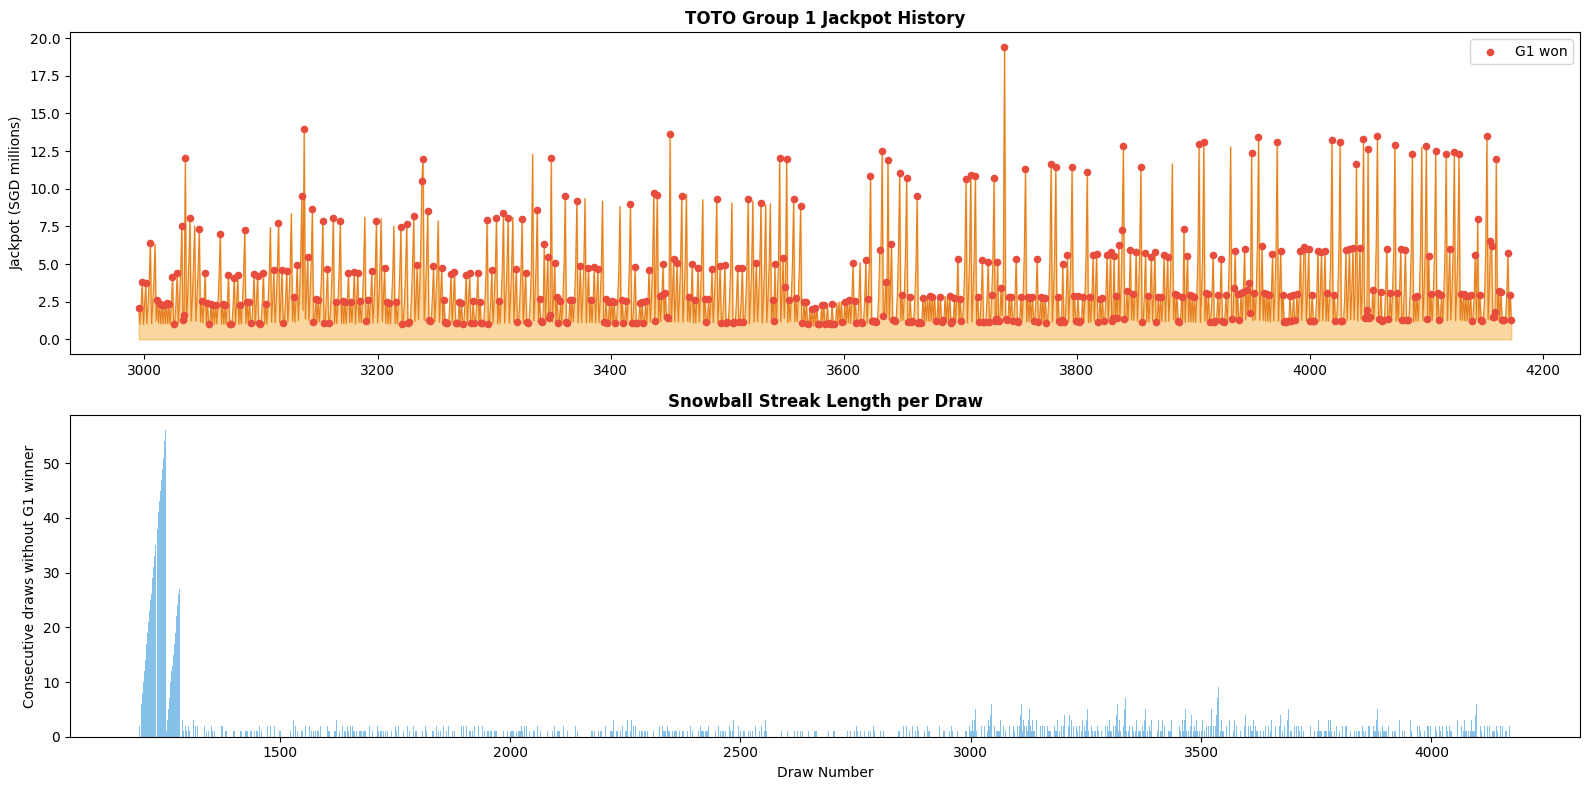

📊 Saved: output/toto_v2_block4_jackpot.png


In [4]:
# Parse jackpot prizes to numeric
def parse_money(s):
    if not s or s == '-':
        return None
    cleaned = re.sub(r'[^\d.]', '', str(s))
    if not cleaned:          # ← catches empty string after stripping
        return None
    return float(cleaned)

df_valid['jackpot_num'] = df_valid['jackpot_prize'].apply(parse_money)

# Snowball streaks — consecutive draws with no G1 winner
df_valid['no_g1_winner'] = (
    (df_valid['g1_winners'].isna()) |
    (df_valid['g1_winners'] == 0)
).astype(int)

# Compute streak length
streak, streaks = 0, []
for v in df_valid['no_g1_winner']:
    streak = streak + 1 if v == 1 else 0
    streaks.append(streak)
df_valid['snowball_streak'] = streaks

# Stats
won_draws    = df_valid[df_valid['g1_winners'] > 0]
no_win_draws = df_valid[df_valid['no_g1_winner'] == 1]

print(f'Draws with G1 winner      : {len(won_draws):,}')
print(f'Draws with NO G1 winner   : {len(no_win_draws):,}')
if len(df_valid[df_valid['jackpot_num'].notna()]) > 0:
    top_jackpot = df_valid.nlargest(5, 'jackpot_num')[['draw_number','draw_date','jackpot_prize','g1_winners','snowball_streak']]
    print(f'\nTop 5 highest jackpots:')
    display(top_jackpot)

max_streak = df_valid['snowball_streak'].max()
print(f'\nLongest snowball streak   : {max_streak} consecutive draws without G1 winner')
print(f'Current streak            : {df_valid["snowball_streak"].iloc[-1]} draws')

# ── Jackpot over time chart ──────────────────────────────────────────────────
df_jackpot = df_valid[df_valid['jackpot_num'].notna()].copy()
if len(df_jackpot) > 10:
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    # Top: jackpot prize over time
    axes[0].fill_between(df_jackpot['draw_number'], df_jackpot['jackpot_num'] / 1e6,
                         alpha=0.4, color='#f39c12')
    axes[0].plot(df_jackpot['draw_number'], df_jackpot['jackpot_num'] / 1e6,
                 color='#e67e22', linewidth=0.8)
    # Mark G1 wins
    wins = df_jackpot[df_jackpot['g1_winners'] > 0]
    axes[0].scatter(wins['draw_number'], wins['jackpot_num'] / 1e6,
                    color='#e74c3c', s=20, zorder=5, label='G1 won')
    axes[0].set_ylabel('Jackpot (SGD millions)')
    axes[0].set_title('TOTO Group 1 Jackpot History', fontweight='bold')
    axes[0].legend()

    # Bottom: snowball streak length
    axes[1].bar(df_valid['draw_number'], df_valid['snowball_streak'],
                color='#3498db', alpha=0.6, width=1)
    axes[1].set_ylabel('Consecutive draws without G1 winner')
    axes[1].set_xlabel('Draw Number')
    axes[1].set_title('Snowball Streak Length per Draw', fontweight='bold')

    plt.tight_layout()
    plt.savefig('output/toto_v2_block4_jackpot.png', dpi=150)
    plt.show()
    print('📊 Saved: output/toto_v2_block4_jackpot.png')
else:
    print('ℹ️  Jackpot data too sparse for chart — run scrape_toto.py v2 to populate.')

---
## 📍 BLOCK 5 — Winning Outlet Location Analysis (Feng Shui Angle)
Where were Group 1 winning tickets purchased?  
Which outlets / towns have produced the most winners?

G1 draws with location data : 1,597
Total outlet entries        : 3,026
Unique outlets              : 1,597

🏆 Top 15 outlets that sold the most G1 winning tickets:
   27×  Singapore Pools Account Betting Service - - ( 1 QuickPick System 7 Entry )
   24×  Singapore Pools Account Betting Service - - ( 1 System 7 Entry )
   22×  Singapore Pools Account Betting Service - - ( 1 QuickPick Ordinary Entry )
   22×  Singapore Pools Account Betting Service - - ( 1 Ordinary Entry )
   11×  Ng Teo Guan Self Service - Block 301 Ubi Avenue 1 #01-241 ( 1 QuickPick Ordinary
   11×  Tan Wee Fong Trading - Block 24 Bendemeer Road #01-529 ( 1 QuickPick Ordinary En
   10×  Singapore Pools Suntec City Branch - 3 Temasek Boulevard #B1-143 Suntec City ( 1
    9×  Teo Sook Cheng Agency - Block 293 Yishun Street 22 #01-225 ( 1 System 7 Entry )
    9×  NTUC FairPrice Boon Lay Place - 221 Boon Lay Place #02-200 Boon Lay Shopping Com
    9×  Tan Ah Leck Trading - Bukit Batok Street 11 - Block 151 Bukit Batok Str

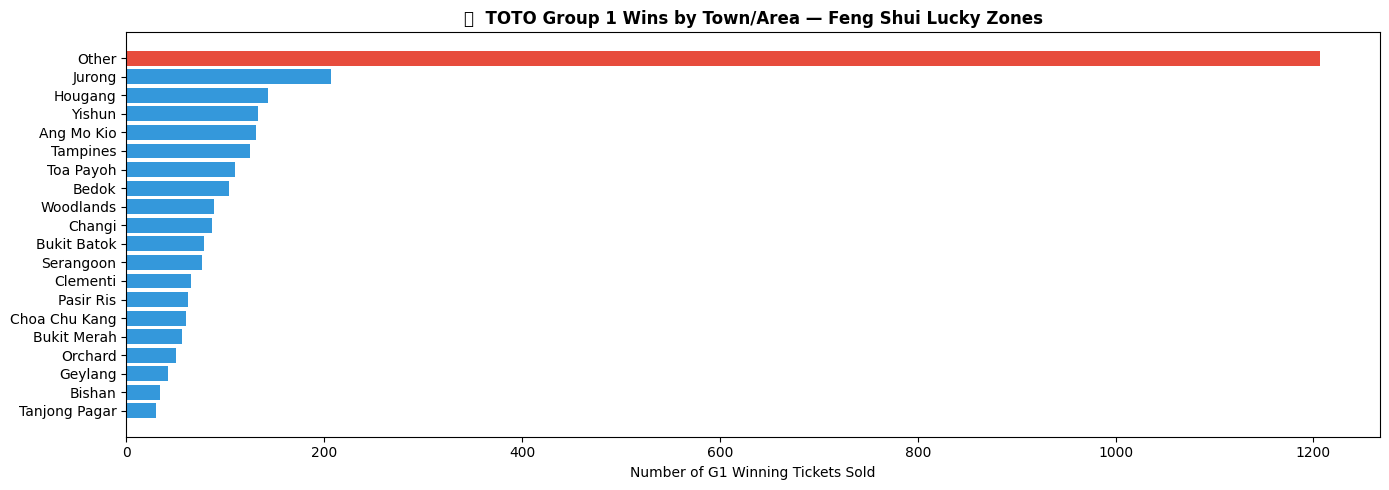

📊 Saved: output/toto_v2_block5_locations.png


In [5]:
if not has_locations:
    print('ℹ️  Location data not in DB yet.')
    print('   Run the new scrape_toto.py v2 to populate g1_locations column.')
else:
    # Parse pipe-separated location strings
    loc_rows = df_valid[df_valid['g1_locations'].notna()][['draw_number','draw_date','g1_locations','g1_winners']]

    # Extract individual outlets
    all_outlets = []
    all_towns   = []

    for _, row in loc_rows.iterrows():
        for outlet in str(row['g1_locations']).split(' | '):
            outlet = outlet.strip()
            if not outlet:
                continue
            all_outlets.append(outlet)
            # Extract town name — usually after 'Block NNN [Town]' or outlet name
            # Pattern: look for common SG town names
            town_match = re.search(
                r'(Tampines|Jurong|Bedok|Woodlands|Yishun|Ang Mo Kio|Bishan|'
                r'Clementi|Hougang|Punggol|Sengkang|Bukit Batok|Bukit Merah|'
                r'Bukit Panjang|Choa Chu Kang|Geylang|Kallang|Queenstown|'
                r'Serangoon|Toa Payoh|Telok Blangah|Canberra|Pasir Ris|'
                r'Marine Parade|Orchard|Raffles|Tanjong Pagar|Novena|'
                r'Buona Vista|Dover|Simei|Changi|Tengah)',
                outlet, re.IGNORECASE
            )
            if town_match:
                all_towns.append(town_match.group(1).title())
            else:
                all_towns.append('Other')

    outlet_counter = Counter(all_outlets)
    town_counter   = Counter(all_towns)

    print(f'G1 draws with location data : {len(loc_rows):,}')
    print(f'Total outlet entries        : {len(all_outlets):,}')
    print(f'Unique outlets              : {len(outlet_counter):,}')

    print(f'\n🏆 Top 15 outlets that sold the most G1 winning tickets:')
    for outlet, count in outlet_counter.most_common(15):
        print(f'  {count:>3}×  {outlet[:80]}')

    print(f'\n🗺️  Winners by town/area:')
    for town, count in town_counter.most_common(20):
        bar = '█' * count
        print(f'  {town:20s} {count:>3}  {bar}')

    # ── Town bar chart ───────────────────────────────────────────────────────
    if len(town_counter) > 1:
        towns_sorted = sorted(town_counter.items(), key=lambda x: x[1], reverse=True)[:20]
        t_names, t_counts = zip(*towns_sorted)

        fig, ax = plt.subplots(figsize=(14, 5))
        colors_t = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(t_names))]
        ax.barh(t_names[::-1], t_counts[::-1], color=colors_t[::-1])
        ax.set_xlabel('Number of G1 Winning Tickets Sold')
        ax.set_title('🗺️  TOTO Group 1 Wins by Town/Area — Feng Shui Lucky Zones', fontweight='bold')
        plt.tight_layout()
        plt.savefig('output/toto_v2_block5_locations.png', dpi=150)
        plt.show()
        print('📊 Saved: output/toto_v2_block5_locations.png')

---
## 🔗 BLOCK 6 — Number Pair Frequency
Which two balls appear together most often? Lottolyzer tracks this — now we do too.
Use the strongest pairs as anchors when building your combo.


Expected pair co-occurrence (random baseline): 37.9 draws

Top 20 most frequent pairs:
  (12, 20)    65x  + 27.1 above expected  █████████████
  (22, 31)    64x  + 26.1 above expected  █████████████
  ( 8, 17)    63x  + 25.1 above expected  ████████████
  (15, 32)    62x  + 24.1 above expected  ████████████
  (30, 31)    62x  + 24.1 above expected  ████████████
  (22, 32)    61x  + 23.1 above expected  ███████████
  ( 9, 23)    61x  + 23.1 above expected  ███████████
  ( 5, 12)    60x  + 22.1 above expected  ███████████
  (21, 30)    60x  + 22.1 above expected  ███████████
  (25, 36)    58x  + 20.1 above expected  ██████████
  (20, 36)    58x  + 20.1 above expected  ██████████
  (22, 36)    58x  + 20.1 above expected  ██████████
  (12, 31)    57x  + 19.1 above expected  █████████
  ( 5, 38)    57x  + 19.1 above expected  █████████
  (22, 37)    57x  + 19.1 above expected  █████████
  ( 1, 36)    57x  + 19.1 above expected  █████████
  ( 7, 30)    56x  + 18.1 above expected  █████████
 

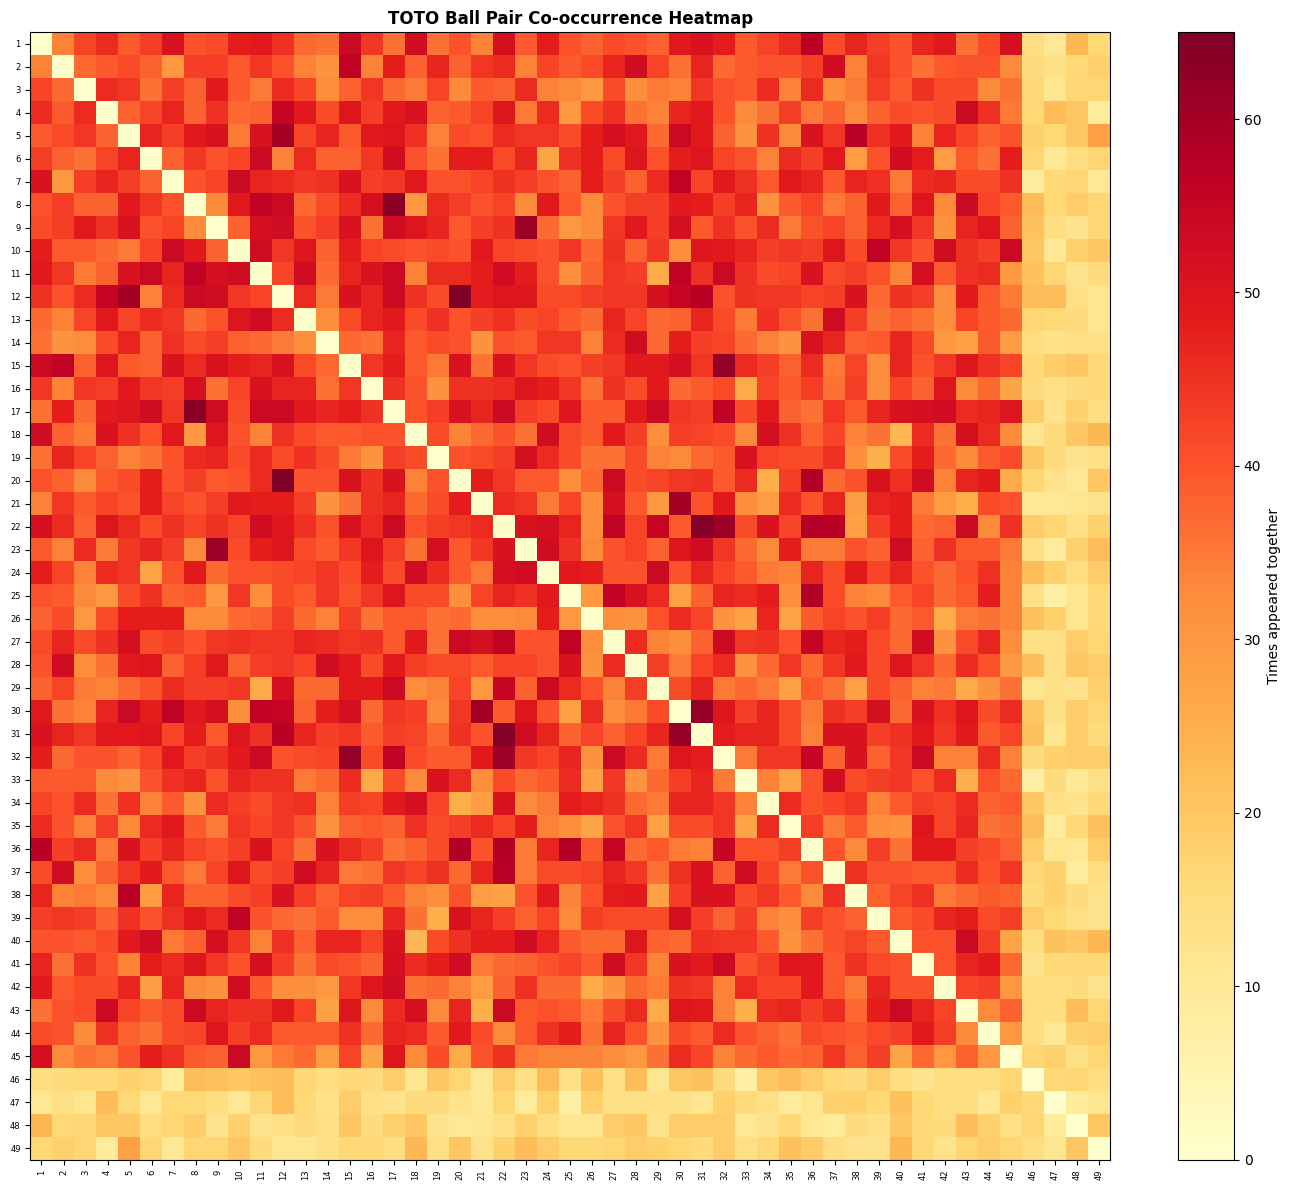

Saved: output/toto_v2_block6_pairs.png


In [6]:
from itertools import combinations as combo_iter

# Count every pair that appeared in the same draw
pair_counter = Counter()
for _, row in df_valid.iterrows():
    balls = sorted([int(row[c]) for c in NUM_COLS])
    for a, b in combo_iter(balls, 2):
        pair_counter[(a, b)] += 1

expected_pair = len(df_valid) * (6/49) * (5/48)
print(f"Expected pair co-occurrence (random baseline): {expected_pair:.1f} draws")
print(f"\nTop 20 most frequent pairs:")
for (a, b), count in pair_counter.most_common(20):
    diff = count - expected_pair
    bar  = chr(9608) * max(0, int(diff/2))
    print(f"  ({a:>2}, {b:>2})  {count:>4}x  +{diff:>5.1f} above expected  {bar}")

# Store top pair numbers for Block 11 output
top_pair_numbers = sorted(set(
    n for pair, _ in pair_counter.most_common(10) for n in pair
))
print(f"\nNumbers in top-10 pairs: {top_pair_numbers}")

# 49x49 heatmap
pair_matrix = np.zeros((50,50), dtype=int)
for (a,b), count in pair_counter.items():
    pair_matrix[a][b] = count
    pair_matrix[b][a] = count

fig, ax = plt.subplots(figsize=(14,12))
dm = pair_matrix[1:50,1:50].astype(float)
np.fill_diagonal(dm, 0)
im = ax.imshow(dm, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Times appeared together")
ax.set_xticks(range(49))
ax.set_yticks(range(49))
ax.set_xticklabels(range(1,50), fontsize=6, rotation=90)
ax.set_yticklabels(range(1,50), fontsize=6)
ax.set_title("TOTO Ball Pair Co-occurrence Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("output/toto_v2_block6_pairs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/toto_v2_block6_pairs.png")


---
## 🎲 BLOCK 7 — Pure Random 7-Ball Combo
One completely unbiased random pick. Every number 1-49 has equal probability.


In [7]:
def gen_pure_random_toto(size=7):
    """Draw `size` unique balls from 1–49 with no bias whatsoever."""
    return sorted(np.random.choice(range(1, 50), size=size, replace=False).tolist())

pure_random_combo = gen_pure_random_toto(COMBO_SIZE)
combo_sum   = sum(pure_random_combo)
above31     = sum(1 for n in pure_random_combo if n > 31)

print('🎲 Pure Random Combo (no bias, rerun for a new one):')
print(f'   Numbers : {pure_random_combo}')
print(f'   Sum     : {combo_sum}')
print(f'   Above 31: {above31}/{COMBO_SIZE}  (higher = less birthday-biased = fewer prize sharers)')
print()

# Historical context
for n in pure_random_combo:
    f = freq.get(n, 0)
    rel = 'HOT 🔴' if n in top7_high else 'COLD 🔵' if n in top7_low else 'neutral'
    print(f'   Ball #{n:>2} — drawn {f} times ({rel})')

🎲 Pure Random Combo (no bias, rerun for a new one):
   Numbers : [6, 15, 16, 25, 31, 32, 49]
   Sum     : 174
   Above 31: 2/7  (higher = less birthday-biased = fewer prize sharers)

   Ball # 6 — drawn 384 times (neutral)
   Ball #15 — drawn 408 times (HOT 🔴)
   Ball #16 — drawn 377 times (neutral)
   Ball #25 — drawn 368 times (neutral)
   Ball #31 — drawn 416 times (HOT 🔴)
   Ball #32 — drawn 403 times (neutral)
   Ball #49 — drawn 157 times (COLD 🔵)


---
## 🔮 BLOCK 8 — Lucky Feel Combo
Uses your LUCKY_NUMBERS from Block 1 as anchors, fills remaining slots
using cold/underdrawn balls to minimise prize sharing.


In [8]:
def derive_lucky_combo(lucky_nums: list, freq: pd.Series,
                        size: int = 7, n_combos: int = 5) -> list:
    """
    Anchors: your personal lucky numbers (must be 1–49)
    Filler : draw remaining slots from coldest available balls
              (least drawn historically = fewest human pickers)
    
    Returns list of (combo, score) tuples.
    """
    # Validate lucky nums
    anchors = []
    for n, reason in lucky_nums:
        try:
            val = int(n)
            if 1 <= val <= 49:
                anchors.append(val)
            else:
                print(f'  ⚠️  {n} out of range 1–49, skipped')
        except:
            print(f'  ⚠️  {n} is not a valid number, skipped')

    anchors = list(set(anchors))[:size]  # deduplicate, cap at size

    if not anchors:
        print('  No valid lucky numbers. Generating cold-ball combos instead.')

    # Remaining slots to fill
    n_fill   = size - len(anchors)
    used     = set(anchors)

    # Cold balls pool — sorted by frequency ascending, exclude anchors
    cold_pool = [n for n in freq.sort_values().index.tolist() if n not in used]

    results = []
    seen    = set()
    attempts = 0

    while len(results) < n_combos and attempts < 500:
        attempts += 1
        # Sample fillers — weight toward cold end with some randomness
        # Take from coldest 20, with slight shuffle for variety
        cold_sample_pool = cold_pool[:min(30, len(cold_pool))]
        fillers = [int(x) for x in np.random.choice(cold_sample_pool,
                                              size=min(n_fill, len(cold_sample_pool)),
                                              replace=False)]
        combo = sorted(anchors + fillers)
        key   = tuple(combo)
        if key not in seen and len(combo) == size:
            seen.add(key)
            score = sum(freq.get(n, 0) for n in combo)  # lower = less popular
            results.append((combo, score))

    return sorted(results, key=lambda x: x[1])  # lowest score first


if LUCKY_NUMBERS:
    lucky_combos = derive_lucky_combo(LUCKY_NUMBERS, freq, size=COMBO_SIZE, n_combos=TOP_N)
    print(f'✅ {len(lucky_combos)} lucky combos generated')
    print(f'   Anchors (your lucky numbers): {[int(n) for n,_ in LUCKY_NUMBERS if n.isdigit() and 1<=int(n)<=49]}')
    print(f'   Fillers: drawn from coldest available balls')
    print()
    for i, (combo, score) in enumerate(lucky_combos, 1):
        above31 = sum(1 for n in combo if n > 31)
        print(f'  Lucky #{i}: {combo}  sum={sum(combo)}  above31={above31}/{COMBO_SIZE}  freq_score={score}')
else:
    lucky_combos = []
    print('ℹ️  No lucky numbers entered in Block 1.')
    print('   Add your personal numbers to LUCKY_NUMBERS to activate this feature.')

✅ 5 lucky combos generated
   Anchors (your lucky numbers): [2, 27, 48, 6, 1, 16]
   Fillers: drawn from coldest available balls

  Lucky #1: [1, 2, 6, 16, 27, 29, 48]  sum=129  above31=1/7  freq_score=2427
  Lucky #2: [1, 2, 6, 16, 19, 27, 48]  sum=119  above31=1/7  freq_score=2437
  Lucky #3: [1, 2, 6, 16, 27, 34, 48]  sum=134  above31=2/7  freq_score=2445
  Lucky #4: [1, 2, 6, 16, 24, 27, 48]  sum=124  above31=1/7  freq_score=2461
  Lucky #5: [1, 2, 6, 16, 27, 41, 48]  sum=141  above31=2/7  freq_score=2467


---
## 🪞 BLOCK 9 — Mirror Number Method (Folk Formula)
Popular YouTube/SG folk method. Last draw numbers -> +6 mod 49 -> mirror digits.
Mirror table: 0<->5, 1<->6, 2<->7, 3<->8, 4<->9, 7=pivot
No statistical basis but culturally resonant. Auto-uses most recent draw.


In [9]:
MIRROR_TABLE = {"0":"5","1":"6","2":"7","3":"8","4":"9",
                "5":"0","6":"1","7":"7","8":"3","9":"4"}

def mirror_number(n):
    m = int("".join(MIRROR_TABLE.get(d,d) for d in str(n)))
    if m < 1:  m = 49 - m
    if m > 49: m = m - 49
    return max(1, min(49, m))

def mirror_formula(nums):
    result = []
    for n in nums:
        s1 = n + 6
        if s1 > 49: s1 -= 49
        result.append(mirror_number(s1))
    return result

last       = df_valid.iloc[-1]
last_nums  = [int(last[c]) for c in NUM_COLS]
last_add   = int(last["additional"]) if pd.notna(last["additional"]) else None
last_date  = last["draw_date"].strftime("%a, %d %b %Y") if pd.notna(last["draw_date"]) else "?"
last_drawno= int(last["draw_number"])

mirror_result = mirror_formula(last_nums)
mirror_combo  = sorted(list(set(mirror_result)))

# Pad to COMBO_SIZE using additional ball mirror if needed
if last_add and len(mirror_combo) < COMBO_SIZE:
    s1 = last_add + 6
    if s1 > 49: s1 -= 49
    extra = mirror_number(s1)
    if extra not in mirror_combo:
        mirror_combo.append(extra)
    mirror_combo = sorted(mirror_combo[:COMBO_SIZE])

print("Mirror Number Method")
print(f"  Based on Draw #{last_drawno} -- {last_date}")
print(f"  Last draw : {last_nums}  Additional: {last_add}")
print()
header = f"  {'Ball':>6}  {'+6':>6}  {'Mirror':>8}"
print(header)
print("  " + "-" * 28)
for n in last_nums:
    s1 = n + 6
    if s1 > 49: s1 -= 49
    s2 = mirror_number(s1)
    print(f"  {n:>6}  {s1:>6}  ->  {s2:>5}")
print()
print(f"  Mirror combo : {mirror_combo}")
print(f"  Sum: {sum(mirror_combo)}  Numbers>31: {sum(1 for n in mirror_combo if n>31)}/{COMBO_SIZE}")
print()
print("  Mirror table: 0<->5  1<->6  2<->7  3<->8  4<->9  7=pivot")
print("  Folk numerology -- no statistical basis")


Mirror Number Method
  Based on Draw #4173 -- Mon, 13 Apr 2026
  Last draw : [4, 8, 10, 15, 16, 26]  Additional: 17

    Ball      +6    Mirror
  ----------------------------
       4      10  ->     16
       8      14  ->     20
      10      16  ->     12
      15      21  ->     27
      16      22  ->     28
      26      32  ->     38

  Mirror combo : [12, 16, 20, 27, 28, 29, 38]
  Sum: 170  Numbers>31: 1/7

  Mirror table: 0<->5  1<->6  2<->7  3<->8  4<->9  7=pivot
  Folk numerology -- no statistical basis


---
## 🏆 BLOCK 10 — Weekly Output: All Your Picks
All combos from every method printed together in one place.
Also shows current jackpot size and snowball streak so you know
whether this is a big draw worth playing more entries.
CSV auto-saved to `output/` folder with timestamp.


In [10]:
# Current jackpot context
latest = df_valid.iloc[-1]
current_streak = int(df_valid['snowball_streak'].iloc[-1])

print('═' * 65)
print(f'  🎱 TOTO WEEKLY PICKS')
print(f'  Generated  : {datetime.now().strftime("%A, %d %B %Y %H:%M")}')
print(f'  Data       : {total_draws:,} valid draws')
print(f'  Latest draw: #{int(latest["draw_number"])} — {latest["draw_date"].date()}')
print(f'  Jackpot    : {latest["jackpot_prize"] or "Unknown"}')
print(f'  Snowball   : {current_streak} consecutive draws without G1 winner')
print(f'  Draw days  : Monday · Thursday')
print('═' * 65)



def print_combo_row(rank, combo, tag=''):
    combo_sum = sum(combo)
    above31   = sum(1 for n in combo if n > 31)
    hot_in    = [n for n in combo if n in top7_high]
    cold_in   = [n for n in combo if n in top7_low]
    print(f'  #{rank:<2}  {str(combo):<35}  '
          f'sum={combo_sum:<4}  >31:{above31}/{COMBO_SIZE}  '
          f'hot:{hot_in}  cold:{cold_in}  {tag}')

# ── 1. Hot balls combo ───────────────────────────────────────────────────────
print(f'\n🔴 HOT BALLS COMBO (top 7 most drawn all-time):')
print('   ' + '─' * 60)
hot_combo = sorted(top7_high)
print_combo_row(1, hot_combo)

# ── 2. Cold balls combo ──────────────────────────────────────────────────────
print(f'\n🔵 COLD BALLS COMBO (top 7 least drawn all-time):')
print('   ' + '─' * 60)
cold_combo = sorted(top7_low)
print_combo_row(1, cold_combo)

# ── 3. Pure random ───────────────────────────────────────────────────────────
print(f'\n🎲 PURE RANDOM COMBO (unbiased, new every run):')
print('   ' + '─' * 60)
print_combo_row(1, pure_random_combo)

# ── 4. Lucky feel ────────────────────────────────────────────────────────────
if lucky_combos:
    print(f'\n🔮 LUCKY FEEL COMBOS (your numbers + cold fillers):')
    print('   ' + '─' * 60)
    for i, (combo, score) in enumerate(lucky_combos, 1):
        print_combo_row(i, combo)
else:
    print(f'\n🔮 LUCKY FEEL COMBOS: (add to LUCKY_NUMBERS in Block 1)')

print()
print('─' * 65)
print('  Prize structure:')
print('  G1 (6 nums)   = share jackpot  |  G2 (5+add) = share G2 pool')
print('  G3 (5 nums)   = share G3 pool  |  Ordinary $1/entry')
print('  System 7 covers all 7 combos of 6 from your 7 numbers = $7')
print('─' * 65)
print('  ⚠️  Odds of winning G1: 1 in 13,983,816 (standard)')
print('      These combos do NOT improve your odds — only your feel.')
print('─' * 65)

# ── Save to CSV ──────────────────────────────────────────────────────────────
rows = []
rows.append({'combo': str(hot_combo),         'method': 'hot_balls',    'sum': sum(hot_combo)})
rows.append({'combo': str(cold_combo),         'method': 'cold_balls',   'sum': sum(cold_combo)})
rows.append({'combo': str(pure_random_combo),  'method': 'pure_random',  'sum': sum(pure_random_combo)})
for i, (combo, _) in enumerate(lucky_combos, 1):
    rows.append({'combo': str(combo), 'method': f'lucky_{i}', 'sum': sum(combo)})

if mirror_combo:
    rows.append({'combo': str(mirror_combo), 'method': 'mirror', 'sum': sum(mirror_combo)})
    
out_df   = pd.DataFrame(rows)
out_file = f'output/toto_picks_{datetime.now().strftime("%Y%m%d_%H%M")}.csv'
out_df.to_csv(out_file, index=False)
print(f'\n💾 Saved: {out_file}')

═════════════════════════════════════════════════════════════════
  🎱 TOTO WEEKLY PICKS
  Generated  : Thursday, 16 April 2026 16:29
  Data       : 2,975 valid draws
  Latest draw: #4173 — 2026-04-13
  Jackpot    : $1,267,460
  Snowball   : 0 consecutive draws without G1 winner
  Draw days  : Monday · Thursday
═════════════════════════════════════════════════════════════════

🔴 HOT BALLS COMBO (top 7 most drawn all-time):
   ────────────────────────────────────────────────────────────
  #1   [11, 12, 15, 17, 22, 30, 31]         sum=138   >31:0/7  hot:[11, 12, 15, 17, 22, 30, 31]  cold:[]  

🔵 COLD BALLS COMBO (top 7 least drawn all-time):
   ────────────────────────────────────────────────────────────
  #1   [3, 26, 45, 46, 47, 48, 49]          sum=264   >31:5/7  hot:[]  cold:[3, 26, 45, 46, 47, 48, 49]  

🎲 PURE RANDOM COMBO (unbiased, new every run):
   ────────────────────────────────────────────────────────────
  #1   [6, 15, 16, 25, 31, 32, 49]          sum=174   >31:2/7  hot:[15,

---
## 🗺️ BLOCK 11 — Ball Heatmap (49-ball grid)
Visual grid of all 49 balls coloured by historical frequency.
- 🔴 Red = drawn most (hot)
- 🔵 Blue = drawn least (cold)
- 🔮 Star = your personal lucky numbers from Block 1


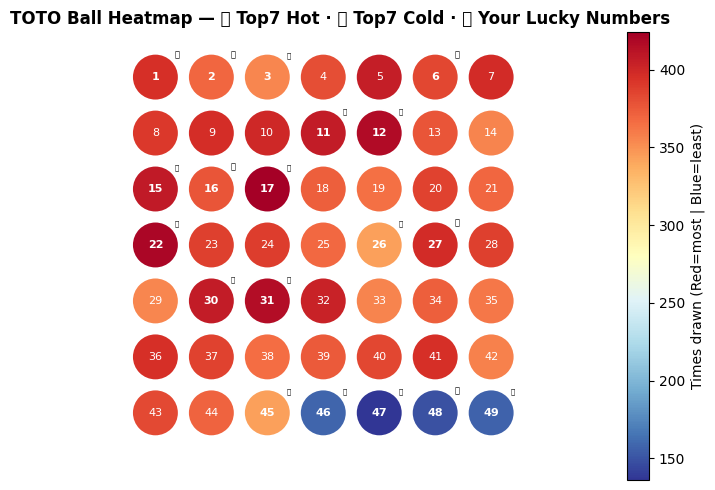

📊 Saved: output/toto_v2_block9_heatmap.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

norm = plt.Normalize(freq.min(), freq.max())
cmap = plt.cm.RdYlBu_r   # Red=hot, Blue=cold

for i, num in enumerate(range(1, 50)):
    row = i // 7
    col = i % 7
    color  = cmap(norm(freq[num]))
    circle = plt.Circle((col, -row), 0.42, color=color, ec='white', lw=1.5)
    ax.add_patch(circle)

    # Label style
    is_top7_hot  = num in top7_high
    is_top7_cold = num in top7_low
    is_lucky     = num in [int(n) for n,_ in LUCKY_NUMBERS if n.isdigit() and 1<=int(n)<=49]

    ax.text(col, -row, str(num), ha='center', va='center',
            fontsize=8,
            fontweight='bold' if (is_top7_hot or is_top7_cold or is_lucky) else 'normal',
            color='white')

    if is_lucky:
        ax.text(col + 0.35, -row + 0.35, '🔮', fontsize=6)
    elif is_top7_hot:
        ax.text(col + 0.35, -row + 0.35, '🔴', fontsize=5)
    elif is_top7_cold:
        ax.text(col + 0.35, -row + 0.35, '🔵', fontsize=5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Times drawn (Red=most | Blue=least)')
ax.set_xlim(-0.6, 7.2)
ax.set_ylim(-7.2, 0.8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('TOTO Ball Heatmap — 🔴 Top7 Hot · 🔵 Top7 Cold · 🔮 Your Lucky Numbers',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('output/toto_v2_block9_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: output/toto_v2_block9_heatmap.png')

---
## ⚙️ BLOCK 12 — Wheeling System Helper
Pick 8-12 numbers. System generates ALL 7-ball combos from your pool.
Guarantee: if pool contains the 6 winning balls, one entry wins G1.


In [12]:
# Edit WHEEL_NUMBERS with your chosen pool (8-12 numbers)
# Leave empty [] to auto-fill from hot balls + lucky numbers
WHEEL_NUMBERS = []

if not WHEEL_NUMBERS:
    anchor = [int(n) for n,_ in LUCKY_NUMBERS if n.isdigit() and 1<=int(n)<=49]
    WHEEL_NUMBERS = sorted(list(set(top7_high[:4] + anchor)))[:10]
    print(f"Auto-filled WHEEL_NUMBERS: {WHEEL_NUMBERS}")
    print("Edit WHEEL_NUMBERS in this block to customise.")
    print()

wheel_pool = sorted(list(set(int(n) for n in WHEEL_NUMBERS if 1<=int(n)<=49)))

if len(wheel_pool) < COMBO_SIZE:
    print(f"Need at least {COMBO_SIZE} numbers. Got {len(wheel_pool)}.")
else:
    wheel_combos = [list(c) for c in combo_iter(wheel_pool, COMBO_SIZE)]
    cost = len(wheel_combos) * 7
    print(f"WHEELING SYSTEM")
    print(f"  Pool ({len(wheel_pool)} numbers): {wheel_pool}")
    print(f"  Total System {COMBO_SIZE} entries : {len(wheel_combos):,}")
    print(f"  Total cost            : ${cost:,} SGD  ({len(wheel_combos)} x $7)")
    print()
    show = min(20, len(wheel_combos))
    for i, c in enumerate(wheel_combos[:show], 1):
        hot_in = [n for n in c if n in top7_high]
        print(f"  #{i:<3} {c}  sum={sum(c)}  hot:{hot_in}")
    if len(wheel_combos) > show:
        print(f"  ... and {len(wheel_combos)-show} more")
    print()
    print(f"  Guarantee: if {len(wheel_pool)} pool numbers include the 6 winning balls,")
    print(f"  at least 1 System {COMBO_SIZE} entry wins Group 1.")
    print(f"  Pool covers {len(wheel_pool)/49*100:.1f}% of all 49 possible balls.")
    stamp = datetime.now().strftime("%Y%m%d_%H%M")
    wfile = f"output/toto_wheel_{stamp}.csv"
    wdf   = pd.DataFrame([{"combo":str(c),"sum":sum(c)} for c in wheel_combos])
    wdf.to_csv(wfile, index=False)
    print(f"\nSaved: {wfile}")


Auto-filled WHEEL_NUMBERS: [1, 2, 6, 12, 16, 17, 22, 27, 31, 48]
Edit WHEEL_NUMBERS in this block to customise.

WHEELING SYSTEM
  Pool (10 numbers): [1, 2, 6, 12, 16, 17, 22, 27, 31, 48]
  Total System 7 entries : 120
  Total cost            : $840 SGD  (120 x $7)

  #1   [1, 2, 6, 12, 16, 17, 22]  sum=76  hot:[12, 17, 22]
  #2   [1, 2, 6, 12, 16, 17, 27]  sum=81  hot:[12, 17]
  #3   [1, 2, 6, 12, 16, 17, 31]  sum=85  hot:[12, 17, 31]
  #4   [1, 2, 6, 12, 16, 17, 48]  sum=102  hot:[12, 17]
  #5   [1, 2, 6, 12, 16, 22, 27]  sum=86  hot:[12, 22]
  #6   [1, 2, 6, 12, 16, 22, 31]  sum=90  hot:[12, 22, 31]
  #7   [1, 2, 6, 12, 16, 22, 48]  sum=107  hot:[12, 22]
  #8   [1, 2, 6, 12, 16, 27, 31]  sum=95  hot:[12, 31]
  #9   [1, 2, 6, 12, 16, 27, 48]  sum=112  hot:[12]
  #10  [1, 2, 6, 12, 16, 31, 48]  sum=116  hot:[12, 31]
  #11  [1, 2, 6, 12, 17, 22, 27]  sum=87  hot:[12, 17, 22]
  #12  [1, 2, 6, 12, 17, 22, 31]  sum=91  hot:[12, 17, 22, 31]
  #13  [1, 2, 6, 12, 17, 22, 48]  sum=108  hot:[1

---
## 🗓️ BLOCK 13 — Almanac Feng Shui Integration
Pulls today's Chinese Almanac (黄历) data to add luck timing and direction.

**What this adds to your TOTO picks:**
- ⏰ Best hours to go buy your ticket today
- 🧭 Direction to face when purchasing (God of Wealth direction)
- 🚫 Direction to avoid (Evil direction)
- ⚡ Clash zodiac warning — if your animal year clashes today, be cautious
- 📍 Which outlet direction from your home aligns with God of Wealth

Requires `scrape_almanac.py` in the same folder and `data/almanac.db` populated.

In [13]:
# ── Almanac Feng Shui Integration ────────────────────────────────────────────
# Requires scrape_almanac.py in same directory
# Run: python scrape_almanac.py --print --timezone sg  to populate almanac.db

import importlib.util, sys
from datetime import date as _date

ALMANAC_TIMEZONE = 'sg'   # ← change to 'germany', 'uk' etc. if needed
YOUR_ZODIAC      = 'Horse'  # ← your Chinese zodiac year animal

# Try to load almanac module
spec = importlib.util.spec_from_file_location(
    "scrape_almanac",
    os.path.join(os.path.dirname(os.path.abspath("__file__")), "scrape_almanac.py")
)

almanac_data = None
if spec and spec.loader:
    try:
        almanac_mod  = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(almanac_mod)
        target_str   = _date.today().strftime('%Y-%m-%d')
        almanac_data = almanac_mod.get_almanac(target_str, timezone=ALMANAC_TIMEZONE)
    except Exception as e:
        print(f'⚠️  Could not load almanac: {e}')
        print('   Make sure scrape_almanac.py is in the same folder.')

if almanac_data:
    print('═' * 65)
    print('  🗓️  ALMANAC FENG SHUI — TODAY\'s Buying Guidance')
    print('═' * 65)
    print(f'  Date       : {almanac_data.get("gregorian_date")} ({almanac_data.get("day_of_week")})')
    print(f'  农历 Lunar  : {almanac_data.get("lunar_date")}')
    print(f'  Day Pillar : {almanac_data.get("day_pillar")}  ({almanac_data.get("day_pillar_zh","")})')
    print()

    # Clash warning
    clash = almanac_data.get('clash_zodiac', '')
    if clash and YOUR_ZODIAC.lower() == clash.lower():
        print(f'  ⚠️  YOUR ZODIAC ({YOUR_ZODIAC}) CLASHES TODAY — consider skipping or buying less')
    else:
        print(f'  ✅ Your zodiac ({YOUR_ZODIAC}) does not clash today (clash = {clash})')
    print(f'  🚫 Evil direction today : {almanac_data.get("evil_direction")} — avoid facing this')
    print()

    # Directions
    print('  🧭 AUSPICIOUS DIRECTIONS FOR BUYING')
    print(f'     财神 God of Wealth    : {almanac_data.get("god_of_wealth","—")}')
    print(f'         → Face {almanac_data.get("god_of_wealth","—")} when purchasing your ticket')
    print(f'         → Buy from an outlet that is {almanac_data.get("god_of_wealth","—")} of your home')
    print(f'     喜神 God of Joy       : {almanac_data.get("god_of_joy","—")}')
    print(f'     贵神 God of Happiness : {almanac_data.get("god_of_happiness","—")}')
    print()

    # Best hours
    ausp = [t for t in (almanac_data.get('auspicious_times') or '').split(' | ') if t]
    if not ausp and almanac_data.get('hourly_json'):
        import json as _json
        hourly = _json.loads(almanac_data['hourly_json'])
        ausp   = [h['time_gmt8'] for h in hourly if h.get('luck') == 'Good']

    print(f'  ⏰ BEST TIMES TO BUY TICKET (SGT / GMT+8):')
    for t in ausp:
        print(f'     ✅ {t}')

    print()

    print()
    print('  📋 YOUR ACTION PLAN FOR TODAY:')
    print(f'     1. Go buy during  : {ausp[0] if ausp else "check above"}')
    print(f'     2. Face direction  : {almanac_data.get("god_of_wealth","—")} when at the counter')
    print(f'     3. Choose outlet   : one that is {almanac_data.get("god_of_wealth","—")} of your home')
    print(f'     4. Avoid facing    : {almanac_data.get("evil_direction","—")}')
    if clash and YOUR_ZODIAC.lower() == clash.lower():
        print(f'     5. ⚠️  Your zodiac clashes today — buy less, or skip')
    else:
        print(f'     5. ✅ Your Horse zodiac is clear today')
    
    # Daily suit/avoid
    print(f'  ✅ 宜 Today suits : {almanac_data.get("auspicious_acts","—")}')
    print(f'  ❌ 忌 Avoid today : {almanac_data.get("inauspicious_acts","—")}')
    print()
    print('  Source: chinese-calendar.net + chinesecalendaronline.com')
    print('═' * 65)
else:
    print('ℹ️  Almanac data not available.')
    print('   Run: python scrape_almanac.py --from 2026-01-01 --to 2026-12-31')
    print('   Then rerun this block.')

═════════════════════════════════════════════════════════════════
  🗓️  ALMANAC FENG SHUI — TODAY's Buying Guidance
═════════════════════════════════════════════════════════════════
  Date       : 2026-04-16 (Thursday)
  农历 Lunar  : February 29, 2026
  Day Pillar : Geng Shen (庚 申) Water Monkey  (庚申)

  ✅ Your zodiac (Horse) does not clash today (clash = Tiger)
  🚫 Evil direction today : South — avoid facing this

  🧭 AUSPICIOUS DIRECTIONS FOR BUYING
     财神 God of Wealth    : East
         → Face East when purchasing your ticket
         → Buy from an outlet that is East of your home
     喜神 God of Joy       : Northwest
     贵神 God of Happiness : Southwest

  ⏰ BEST TIMES TO BUY TICKET (SGT / GMT+8):
     ✅ 23:00-00:59
     ✅ 01:00-02:59
     ✅ 07:00-08:59
     ✅ 09:00-10:59
     ✅ 13:00-14:59
     ✅ 19:00-20:59


  📋 YOUR ACTION PLAN FOR TODAY:
     1. Go buy during  : 23:00-00:59
     2. Face direction  : East when at the counter
     3. Choose outlet   : one that is East of your hom

---
## 🔁 BLOCK 14 — Weekly Rerun Checklist
```
Before every TOTO draw (Monday / Thursday):

[ ] 1. python scrape_toto.py       → updates toto_results.db
[ ] 2. python scrape_almanac.py    → updates today's almanac.db
[ ] 3. Update LUCKY_NUMBERS in Block 1 (new signs this week?)
[ ] 4. Update YOUR_ZODIAC in Block 13 if needed
[ ] 5. Update WHEEL_NUMBERS in Block 12 if using wheeling
[ ] 6. Kernel → Restart & Run All
[ ] 7. Block 4  : snowball streak? Big jackpot this draw?
[ ] 8. Block 9  : pick your combo from hot/cold/random/lucky
[ ] 9. Block 10 : check mirror numbers from latest draw
[ ] 10. Block 13: TODAY's best time + direction + outlet
[ ] 11. All CSVs auto-saved in output/ folder
```


In [14]:
conn.close()
print('✅ All done. DB connection closed.')
print('Next TOTO draws: Monday · Thursday')
print('Rerun: Kernel → Restart & Run All')

✅ All done. DB connection closed.
Next TOTO draws: Monday · Thursday
Rerun: Kernel → Restart & Run All
